In [3]:
!pip install -r ../requirements.txt

  Using cached pandas-3.0.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 580.7 kB/s eta 0:00:00a 0:00:01
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 1.5 MB/s eta 0:00:0000:01
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.0/125.0 kB 2.3 MB/s eta 0:00:00a 0:00:01
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4

# Загрузка данных из kaggle

In [ ]:
import os
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("gauravmalik26/food-delivery-dataset")

print("Путь к скачанным файлам:", path)

csv_file = os.path.join(path, "train.csv")
df = pd.read_csv(csv_file)

df.head()

/home/nadia/food-delivery-ops-analytics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.95M/1.95M [00:00<00:00, 2.24MB/s]

Extracting files...


Путь к скачанным файлам: /home/nadia/.cache/kagglehub/datasets/gauravmalik26/food-delivery-dataset/versions/1


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


# Первичный EDA и очистка данных

In [ ]:
import os
import pandas as pd
import numpy as np
import kagglehub

path = kagglehub.dataset_download("gauravmalik26/food-delivery-dataset")
csv_path = os.path.join(path, "train.csv")
df = pd.read_csv(csv_path)

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df['time_taken_min'] = df['time_taken(min)'].str.extract(r'(\d+)').astype(float)

df['time_orderd'] = df['time_orderd'].astype(str).str.strip()
df['time_order_picked'] = df['time_order_picked'].astype(str).str.strip()

df = df.dropna(subset=['time_orderd', 'time_order_picked', 'order_date'])
df = df[(df['time_orderd'] != 'NaN') & (df['time_order_picked'] != 'NaN')]

df['time_ordered'] = pd.to_datetime(df['order_date'] + ' ' + df['time_orderd'], errors='coerce')
df['time_picked'] = pd.to_datetime(df['order_date'] + ' ' + df['time_order_picked'], errors='coerce')

df['prep_time_min'] = (df['time_picked'] - df['time_ordered']).dt.total_seconds() / 60

df = df.dropna(subset=['time_ordered', 'time_picked', 'prep_time_min'])
df = df[(df['prep_time_min'] >= 0) & (df['prep_time_min'] <= 120)]

print(f"✅ Данные успешно очищены! Итоговый размер: {len(df)} строк.")
df[['time_ordered', 'time_picked', 'prep_time_min', 'time_taken_min']].head()

✅ Данные успешно очищены! Итоговый размер: 43031 строк.


/tmp/ipykernel_11887/3876785501.py:26: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time_ordered'] = pd.to_datetime(df['order_date'] + ' ' + df['time_orderd'], errors='coerce')
/tmp/ipykernel_11887/3876785501.py:27: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time_picked'] = pd.to_datetime(df['order_date'] + ' ' + df['time_order_picked'], errors='coerce')


,time_ordered,time_picked,prep_time_min,time_taken_min
0,2022-03-19 11:30:00,2022-03-19 11:45:00,15.0,24.0
1,2022-03-25 19:45:00,2022-03-25 19:50:00,5.0,33.0
2,2022-03-19 08:30:00,2022-03-19 08:45:00,15.0,26.0
3,2022-04-05 18:00:00,2022-04-05 18:10:00,10.0,21.0
4,2022-03-26 13:30:00,2022-03-26 13:45:00,15.0,30.0


# Расчитываем расстояние между точкой отправки (ресторан) и точкой назначения (адрес клиента)

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    # Перевод градусов в радианы
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Формула гаверсинусов
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

# Расчет расстояния в км
df['distance_km'] = haversine_distance(
    df['restaurant_latitude'], df['restaurant_longitude'],
    df['delivery_location_latitude'], df['delivery_location_longitude']
)

df = df[(df['distance_km'] > 0) & (df['distance_km'] <= 30)]

print("✅ Расстояние успешно рассчитано!")
df[['restaurant_latitude', 'delivery_location_latitude', 'distance_km']].head()

✅ Расстояние успешно рассчитано!


,restaurant_latitude,delivery_location_latitude,distance_km
0,22.745049,22.765049,3.023250
1,12.913041,13.043041,20.170858
2,12.914264,12.924264,1.551783
3,11.003669,11.053669,7.785510
4,12.972793,13.012793,6.206239


# Графики, которые показывают причины задержки заказа

/tmp/ipykernel_11887/1576531334.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


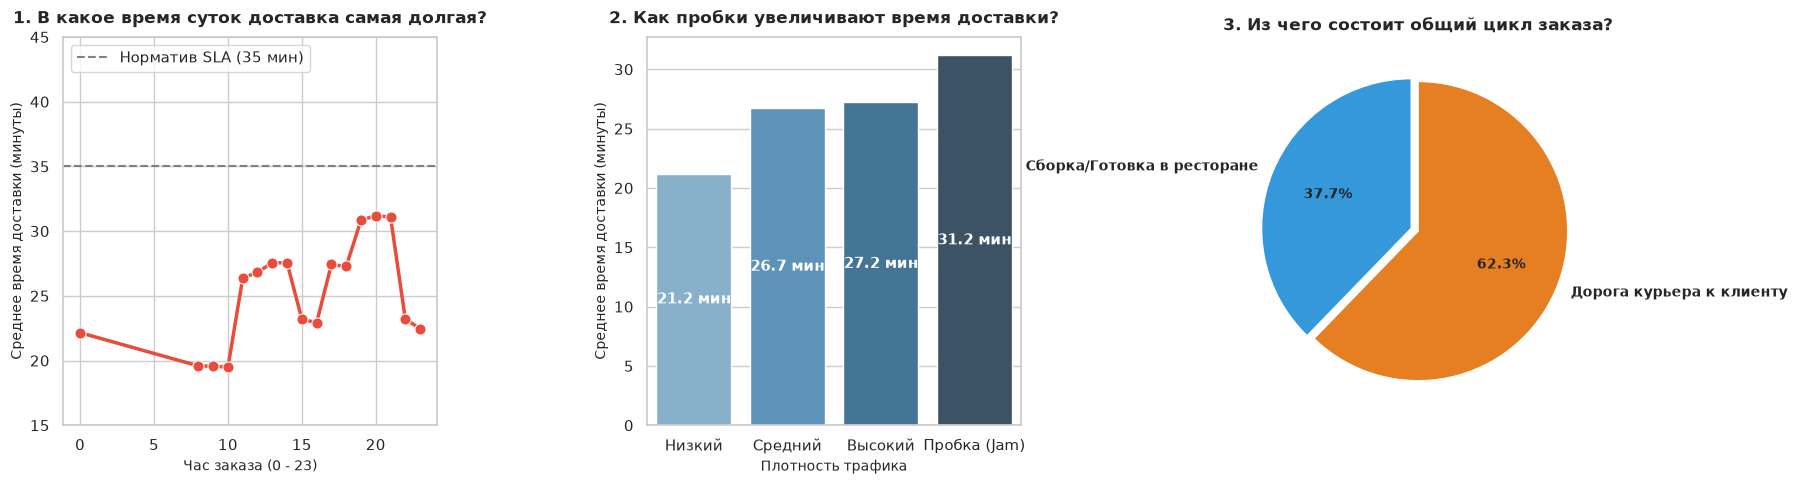

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Предварительная подготовка данных для графиков
# Убираем лишние пробелы из названий категорий трафика
df['road_traffic_density'] = df['road_traffic_density'].astype(str).str.strip()

# Переводим категории трафика на русский язык для наглядности
traffic_map = {
    'Low': 'Низкий',
    'Medium': 'Средний',
    'High': 'Высокий',
    'Jam': 'Пробка (Jam)'
}
df['traffic_ru'] = df['road_traffic_density'].map(traffic_map)

# Фильтруем пустые значения трафика
df_plot = df.dropna(subset=['traffic_ru']).copy()

# Настраиваем общий стиль
sns.set_theme(style="whitegrid", font="sans-serif")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- ГРАФИК 1: Динамика времени доставки по часам (Пиковые нагрузки) ---
df_plot['order_hour'] = df_plot['time_ordered'].dt.hour
hourly_stats = df_plot.groupby('order_hour')['time_taken_min'].mean().reset_index()

sns.lineplot(
    ax=axes[0], data=hourly_stats, x='order_hour', y='time_taken_min',
    marker='o', markersize=8, color='#e74c3c', linewidth=2.5
)
# Линия норматива SLA
axes[0].axhline(35, color='gray', linestyle='--', label='Норматив SLA (35 мин)')
axes[0].set_title('1. В какое время суток доставка самая долгая?', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Час заказа (0 - 23)', fontsize=10)
axes[0].set_ylabel('Среднее время доставки (минуты)', fontsize=10)
axes[0].set_ylim(15, 45)
axes[0].legend(loc='upper left')

# --- ГРАФИК 2: Влияние пробок на время доставки ---
traffic_order = ['Низкий', 'Средний', 'Высокий', 'Пробка (Jam)']
sns.barplot(
    ax=axes[2-1], data=df_plot, x='traffic_ru', y='time_taken_min',
    order=traffic_order, palette='Blues_d', errorbar=None
)

# Подписываем точные точные значения минут над каждым столбиком
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f'{height:.1f} мин',
                            (p.get_x() + p.get_width() / 2., height / 2),
                            ha='center', va='center', fontsize=11, color='white', fontweight='bold')

axes[1].set_title('2. Как пробки увеличивают время доставки?', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Плотность трафика', fontsize=10)
axes[1].set_ylabel('Среднее время доставки (минуты)', fontsize=10)

# --- ГРАФИК 3: Из чего состоит время заказа (Готовка vs Логистика) ---
avg_prep = df_plot['prep_time_min'].mean()
avg_delivery = df_plot['time_taken_min'].mean() - avg_prep

breakdown_data = pd.DataFrame({
    'Этап': ['Сборка/Готовка в ресторане', 'Дорога курьера к клиенту'],
    'Минуты': [avg_prep, avg_delivery]
})

colors = ['#3498db', '#e67e22']
axes[2].pie(
    breakdown_data['Минуты'], labels=breakdown_data['Этап'],
    colors=colors, autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10, 'weight': 'bold'}, explode=(0.05, 0)
)
axes[2].set_title('3. Из чего состоит общий цикл заказа?', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

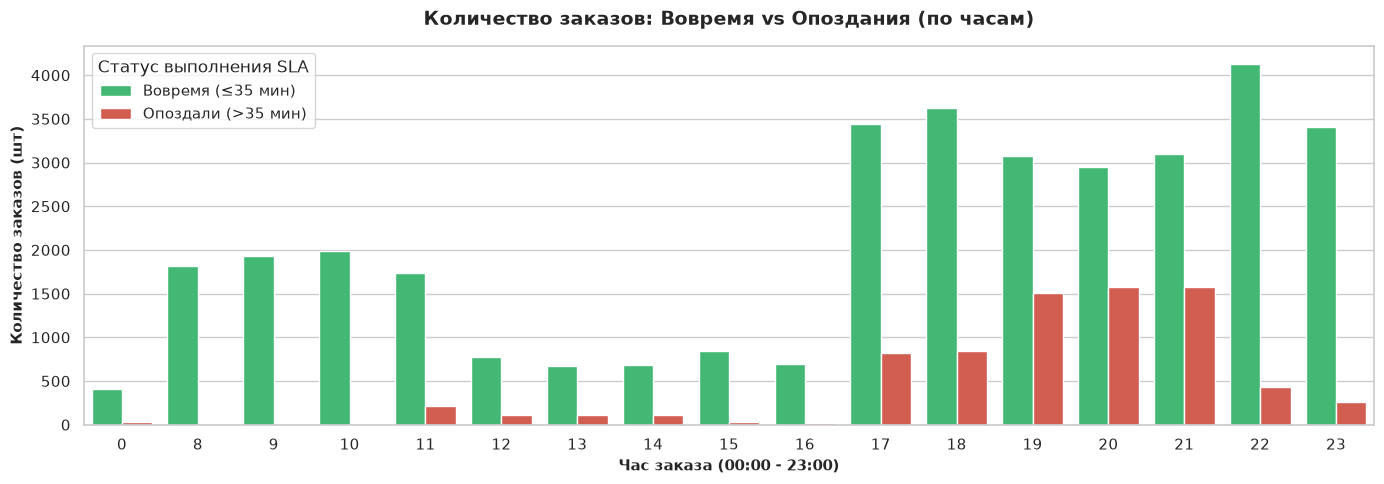

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Размечаем заказы: вовремя или опоздал
SLA_LIMIT = 35
df['sla_status'] = df['time_taken_min'].apply(lambda x: 'Опоздали (>35 мин)' if x > SLA_LIMIT else 'Вовремя (≤35 мин)')

# 2. Группируем по часам и статусу
sla_by_hour = df.groupby(['order_hour', 'sla_status']).size().reset_index(name='count')

# 3. Строим простой и четкий график
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Строим два столбика рядом для каждого часа
ax = sns.barplot(
    data=sla_by_hour, 
    x='order_hour', 
    y='count', 
    hue='sla_status', 
    palette={'Вовремя (≤35 мин)': '#2ecc71', 'Опоздали (>35 мин)': '#e74c3c'}
)

plt.title('Количество заказов: Вовремя vs Опоздания (по часам)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Час заказа (00:00 - 23:00)', fontsize=11, fontweight='bold')
plt.ylabel('Количество заказов (шт)', fontsize=11, fontweight='bold')
plt.legend(title='Статус выполнения SLA', frameon=True)

# Убираем поворот подписей часов
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()